# Пример анализа данных TS

HAR (Human Activity Recognition) dataset — это набор данных для распознавания активности человека на основе данных с датчиков. Обычно такие датасеты содержат информацию, полученную с акселерометров и гироскопов, установленных на теле человека (например, смартфон в кармане или носимые устройства).

Загрузим данный датасет с Kaggle

In [1]:
import kagglehub
erenaktas_human_activity_recognition_path = kagglehub.dataset_download('erenaktas/human-activity-recognition', force_download=True)
datadir = erenaktas_human_activity_recognition_path + "/UCI_HAR_Dataset"

  0%|          | 0.00/119M [00:00<?, ?B/s]

  1%|          | 1.00M/119M [00:04<08:15, 251kB/s]

  2%|▏         | 2.00M/119M [00:05<04:21, 470kB/s]

  3%|▎         | 3.00M/119M [00:06<03:37, 561kB/s]

  3%|▎         | 4.00M/119M [00:07<02:45, 732kB/s]

...

 99%|█████████▉| 118M/119M [03:29<00:03, 416kB/s]

100%|█████████▉| 119M/119M [03:30<00:00, 490kB/s]

100%|██████████| 119M/119M [03:30<00:00, 530kB/s]

100%|██████████| 119M/119M [03:30<00:00, 594kB/s]

Extracting files...


# EDA & Data Visualisation

EDA (Exploratory Data Analysis — разведочный анализ данных) — это начальный этап анализа данных, в котором исследуется их структура, выявляются закономерности, выбросы и аномалии

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid") # https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html
sns.set_style("white") # https://seaborn.pydata.org/generated/seaborn.set_style.html
from mpl_toolkits import mplot3d
from mpl_toolkits.mplot3d import axes3d
import matplotlib as mpl

import os
for dirname, _, filenames in os.walk(datadir):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/Users/abubakir/.cache/kagglehub/datasets/erenaktas/human-activity-recognition/versions/1/UCI_HAR_Dataset/features.txt
/Users/abubakir/.cache/kagglehub/datasets/erenaktas/human-activity-recognition/versions/1/UCI_HAR_Dataset/activity_labels.txt
/Users/abubakir/.cache/kagglehub/datasets/erenaktas/human-activity-recognition/versions/1/UCI_HAR_Dataset/features_info.txt
/Users/abubakir/.cache/kagglehub/datasets/erenaktas/human-activity-recognition/versions/1/UCI_HAR_Dataset/README.txt
/Users/abubakir/.cache/kagglehub/datasets/erenaktas/human-activity-recognition/versions/1/UCI_HAR_Dataset/test/subject_test.txt
/Users/abubakir/.cache/kagglehub/datasets/erenaktas/human-activity-recognition/versions/1/UCI_HAR_Dataset/test/X_test.txt
/Users/abubakir/.cache/kagglehub/datasets/erenaktas/human-activity-recognition/versions/1/UCI_HAR_Dataset/test/y_test.txt
/Users/abubakir/.cache/kagglehub/datasets/erenaktas/human-activity-recognition/versions/1/UCI_HAR_Dataset/test/Inertial Signals/total_acc_y_te

## Data Pipeline
Functions to load the dataset

In [3]:
# load a single file as a numpy array
def load_file(filepath):
    df = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return df.values

# load a list of files into a 3D array of [observations, timesteps, features(x,y,z)]
def load_group(files, prefix=''):
    loaded = list()
    for f in files:
        data = load_file(prefix + f)
        loaded.append(data)
    # stack group so that features are the 3rd dimension
    loaded = np.dstack(loaded)
    return loaded

def load_dataset_group(group, prefix=''):
    filepath = prefix + '/' + group + '/Inertial Signals/'
    # load all 9 files as a single array
    files = list()
    # body acceleration
    files += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    # body gyroscope
    files += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    # total acceleration
    files += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    # load input data
    X = load_group(files, filepath)
    # load class output
    y = load_file(prefix + '/' + group + '/y_'+group+'.txt')
    return X, y

def load_dataset(prefix=''):
    # load all train
    X_train, y_train = load_dataset_group('train', prefix)
    # load all test
    X_test, y_test = load_dataset_group('test', prefix)

    """
    # zero-offset class values
    y_train = y_train - 1
    y_test = y_test - 1
    # one hot encode y
    y_train = to_categorical(y_train)
    y_test = to_categorical(y_test)
    """

    print(f"""Dataset loaded.
Training Set:
X_train {X_train.shape} y_train {y_train.shape}
Test Set:
X_test {X_test.shape} y_test {y_test.shape}""")
    return X_train, y_train, X_test, y_test

In [4]:
X_train, y_train, X_test, y_test = load_dataset(prefix=datadir)

/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)


/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)


/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)


/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)


/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.rea

/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.rea

Dataset loaded.
Training Set:
X_train (7352, 128, 9) y_train (7352, 1)
Test Set:
X_test (2947, 128, 9) y_test (2947, 1)


/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filepath, header=None, delim_whitespace=True)
/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/258127397.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.rea

In [5]:
activity = {
        1: 'Walking',
        2: 'Walking Upstairs',
        3: 'Walking Downstairs',
        4: 'Sitting',
        5: 'Standing',
        6: 'Laying'}
def activities(obs):
    return activity[int(y_train[obs])]

In [6]:
def features(feature):
    f={"Body acceleration": 0, "Gyro": 1, "Total acceleration": 2}
    return f[feature]

In [7]:
# Example for each activity
sample=[777, 666, 818, 0, 6666, 66]
[activity[int(y_train[i])] for i in sample]

/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/4219681044.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  [activity[int(y_train[i])] for i in sample]


['Walking',
 'Walking Upstairs',
 'Walking Downstairs',
 'Standing',
 'Sitting',
 'Laying']

## Data Visualisation
### Feature Signals (xyz)

In [8]:
# Grab values for graphs
def get_values(y_values, T, N, f_s, sample_rate):
    y_values = y_values
    x_values = [sample_rate * kk for kk in range(0,len(y_values))]
    return x_values, y_values

In [9]:
# Display x,y,z as separate lines for each feature
def signal_viz(obs):
    N = 128 # number of timesteps
    f_s = 50 # overlapped percentage
    t_n = 2.56 # time
    T = t_n / N
    sample_rate = 1 / f_s

    labels = ['x-component', 'y-component', 'z-component']
    colors = ['r', 'g', 'b']
    suptitle = "Different signals for the activity: {}"
    graph_name="graph/Signals {}.png"
    xlabel = 'Time [sec]'
    ylabel = 'Amplitude'
    axtitles = ['Body acceleration', 'Gyro', 'Total acceleration']
    activity_name = activities(obs)

    sns.set(style="white", font_scale = 1.7)
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24,8))


    for comp_no in range(0,9):
            col_no = comp_no // 3
            plot_no = comp_no % 3
            color = colors[plot_no]
            label = labels[plot_no]

            axtitle  = axtitles[col_no]

            ax = axes[col_no]
            ax.set_title(axtitle)
            ax.set_xlabel(xlabel)
            if col_no == 0:
                ax.set_ylabel(ylabel, fontsize=16)

            signal_component = X_train[obs][:, comp_no]
            x_values, y_values = get_values(signal_component, T, N, f_s, sample_rate)
            ax.plot(x_values, y_values, linestyle='-', color=color, label=label)
            if col_no == 2:
                ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    fig.suptitle(suptitle.format(activity_name))
    plt.tight_layout()
    plt.subplots_adjust(top=0.90, hspace=0.6)
    plt.show()

/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/2674526311.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return activity[int(y_train[obs])]


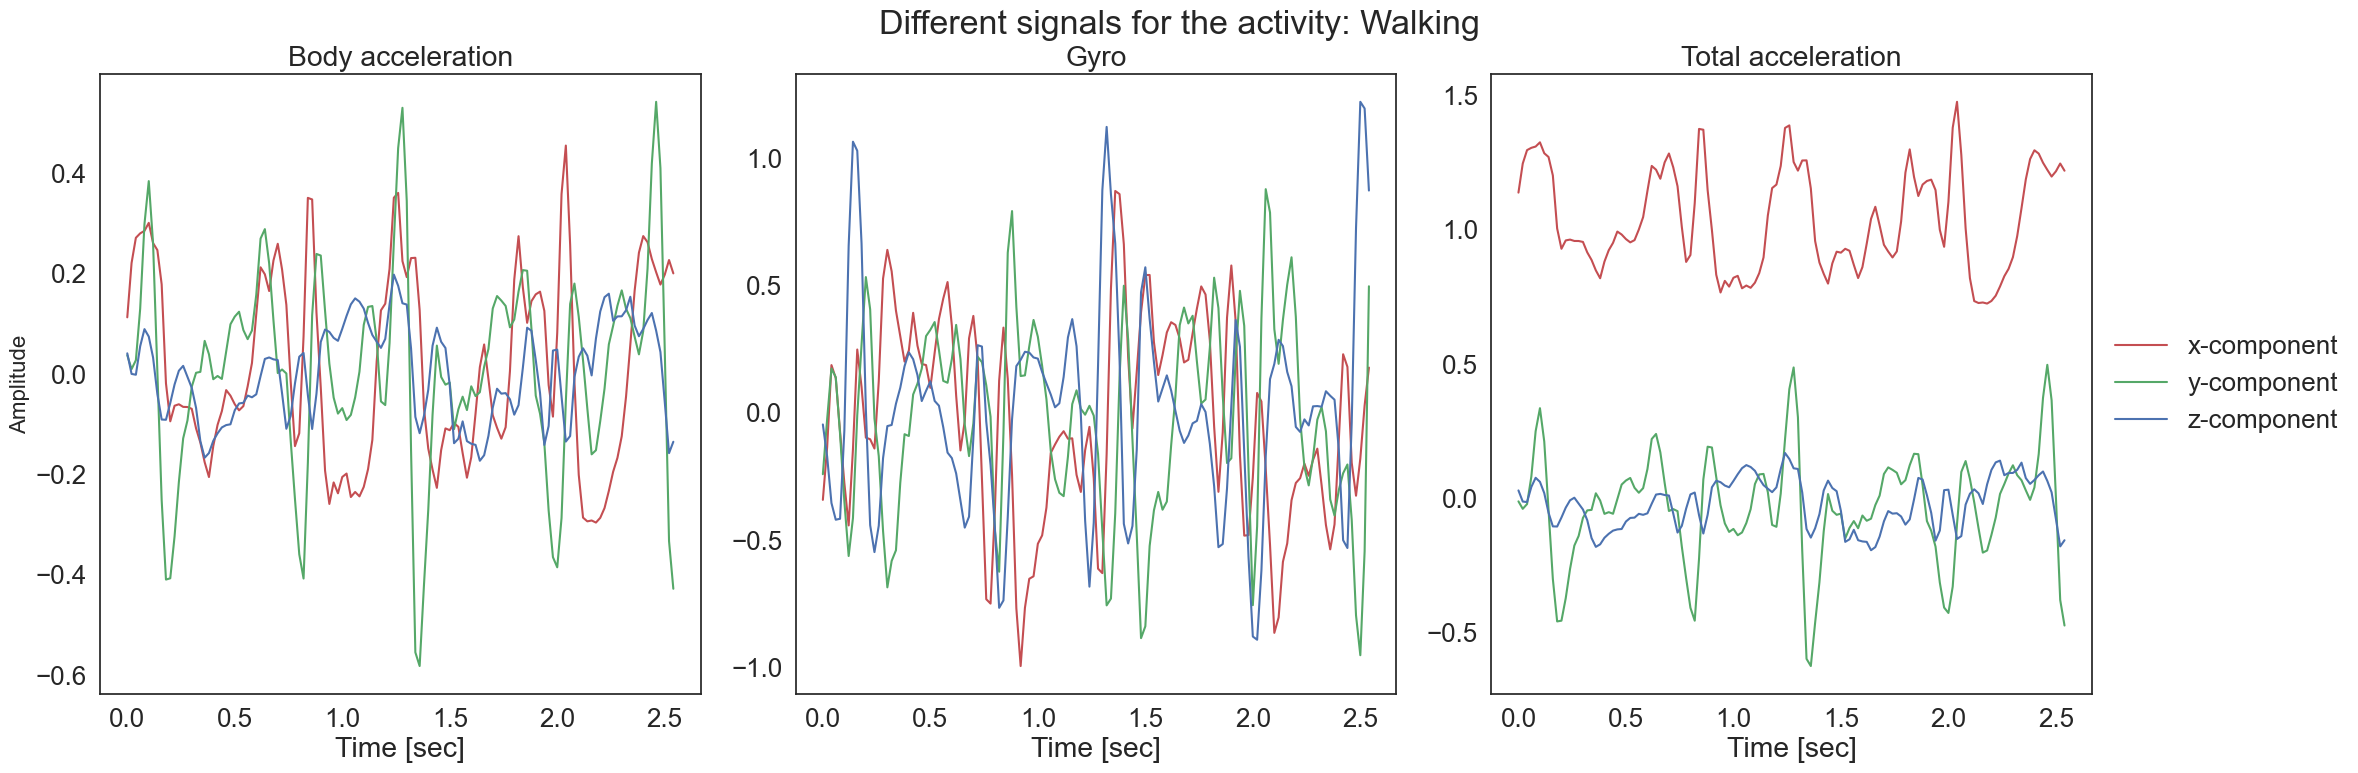

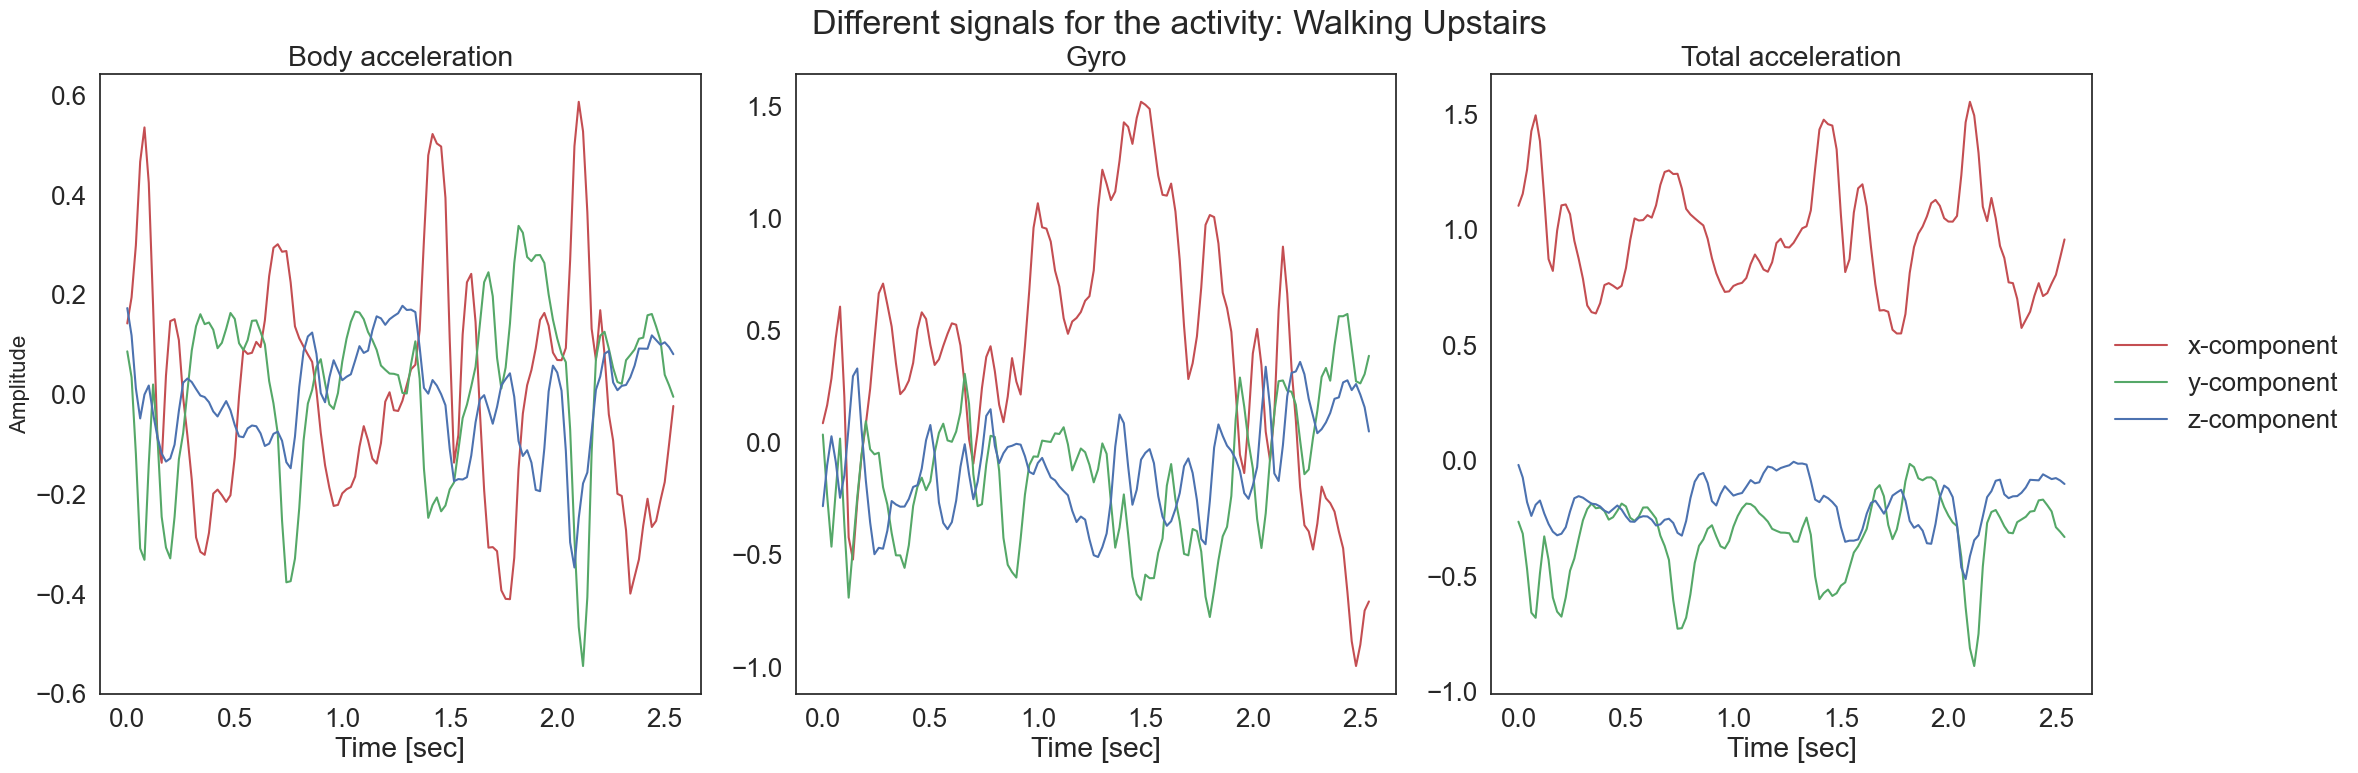

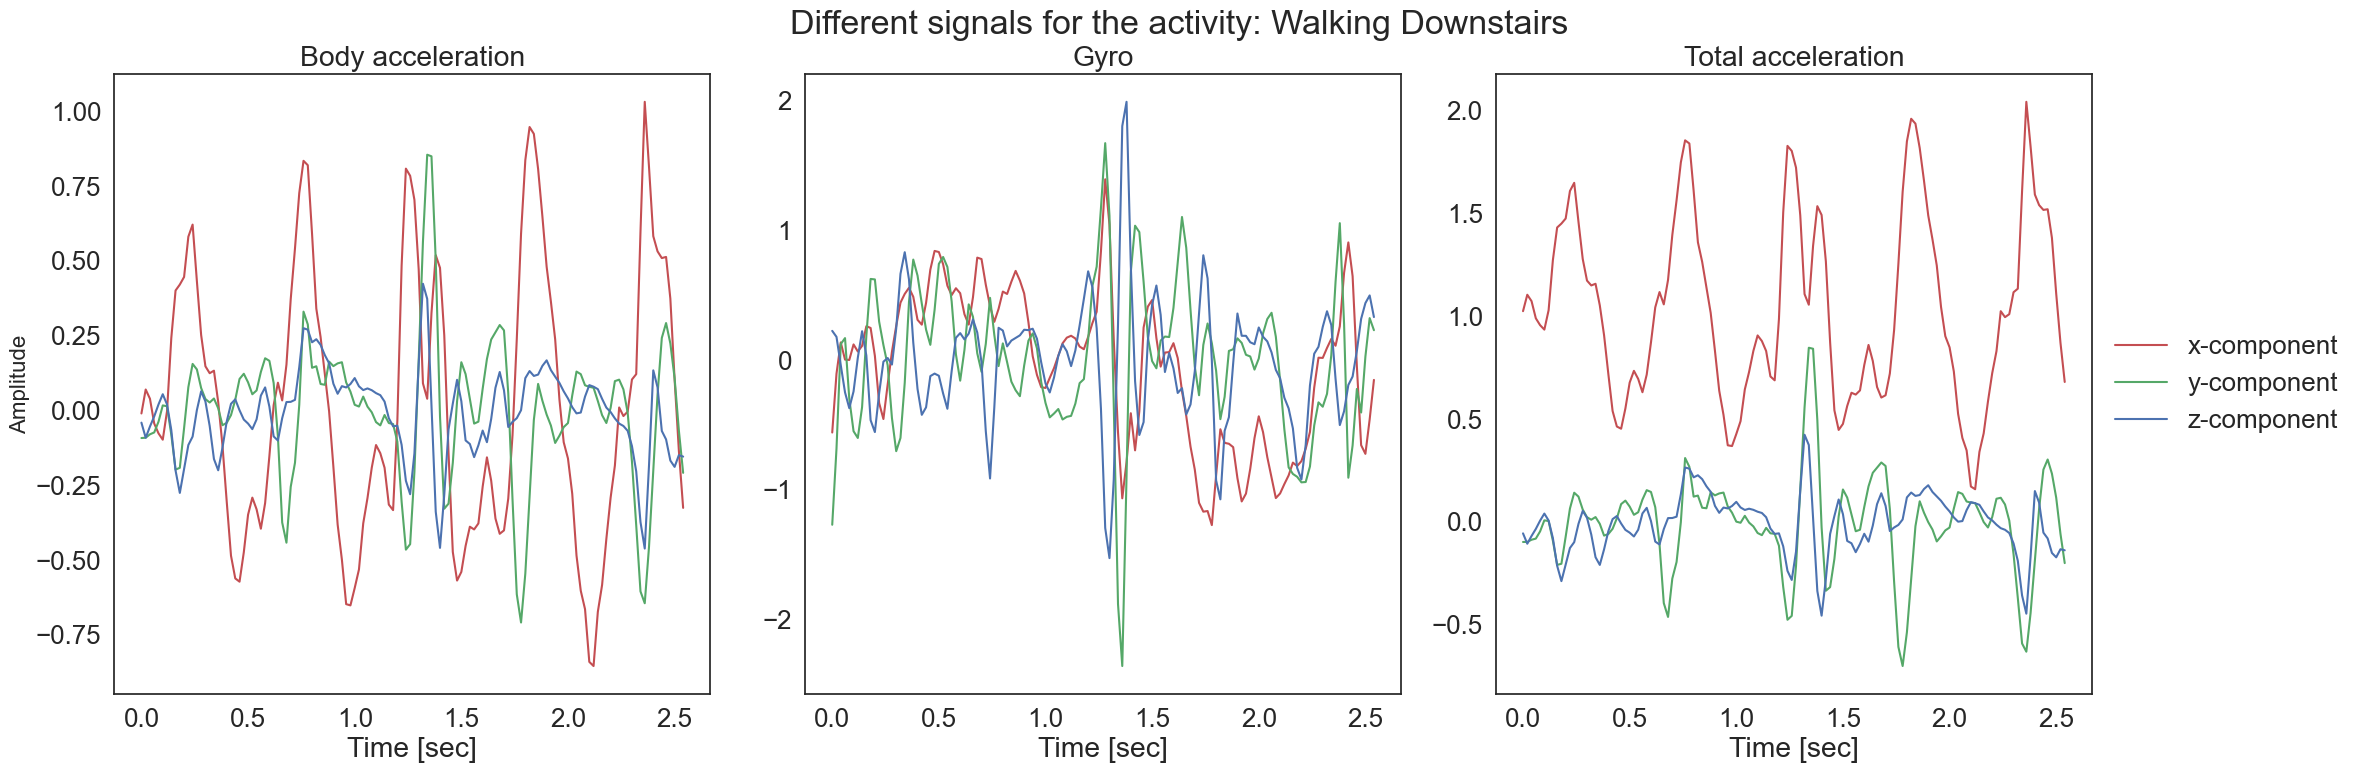

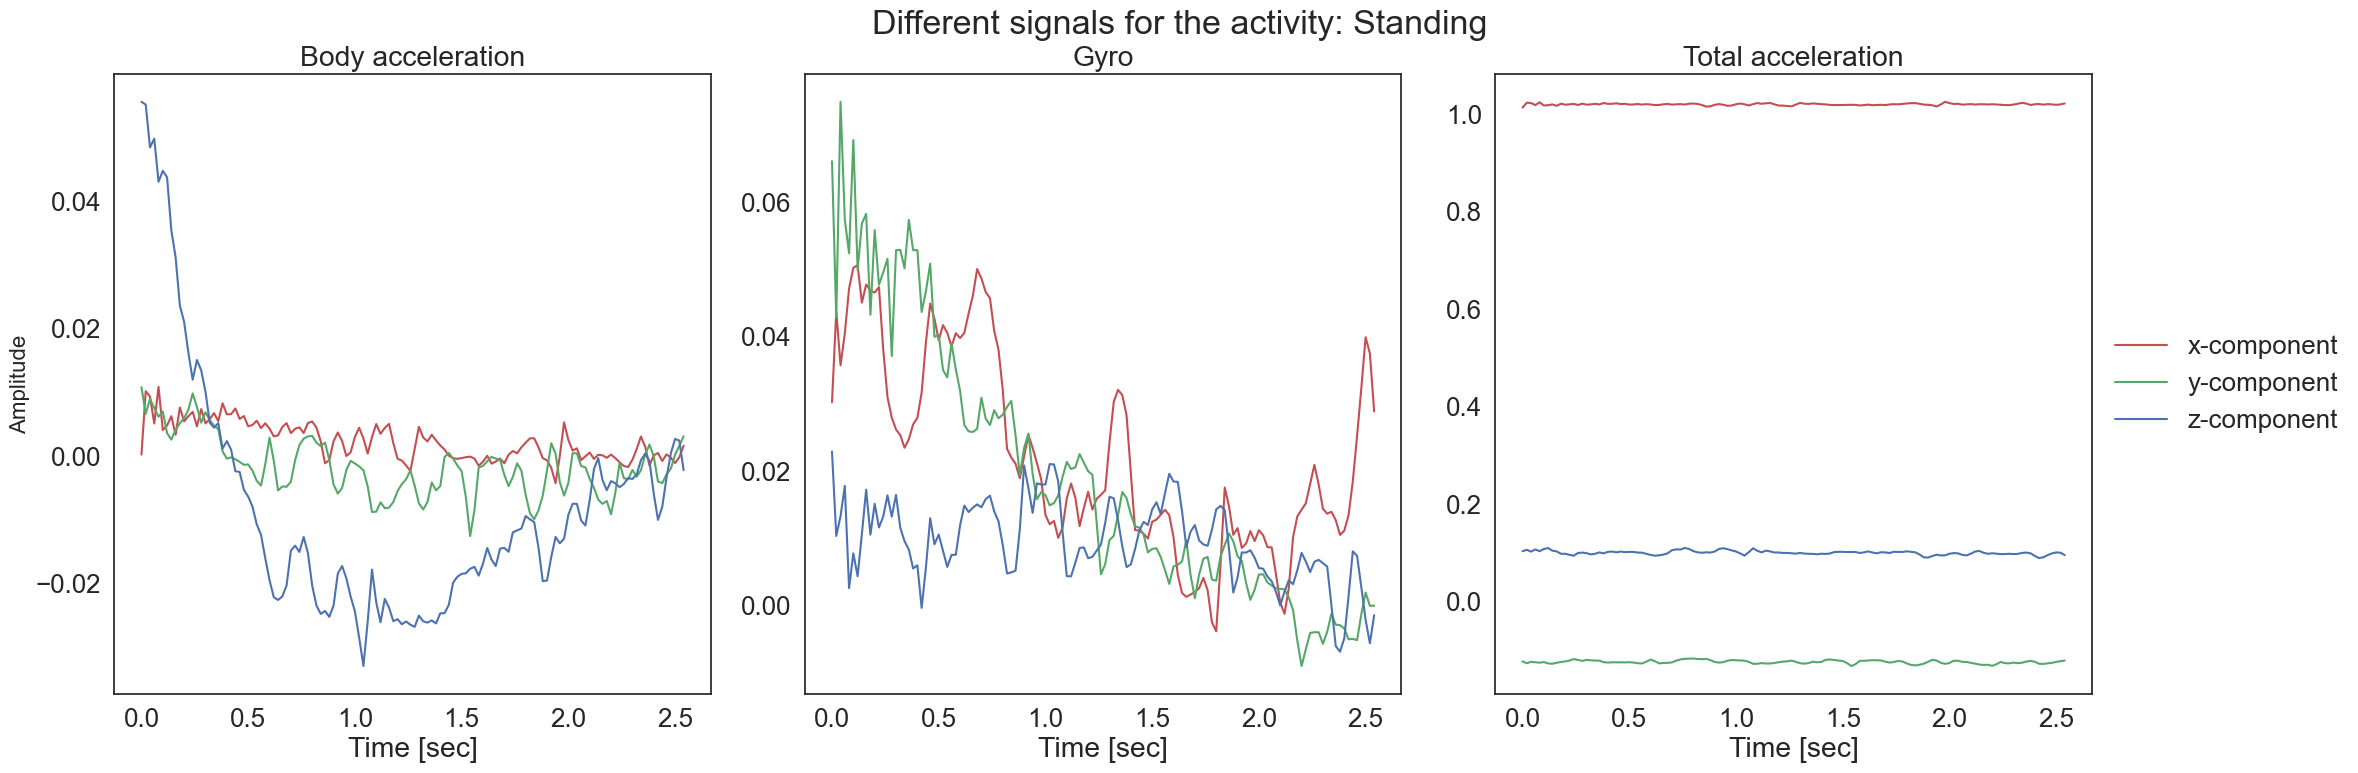

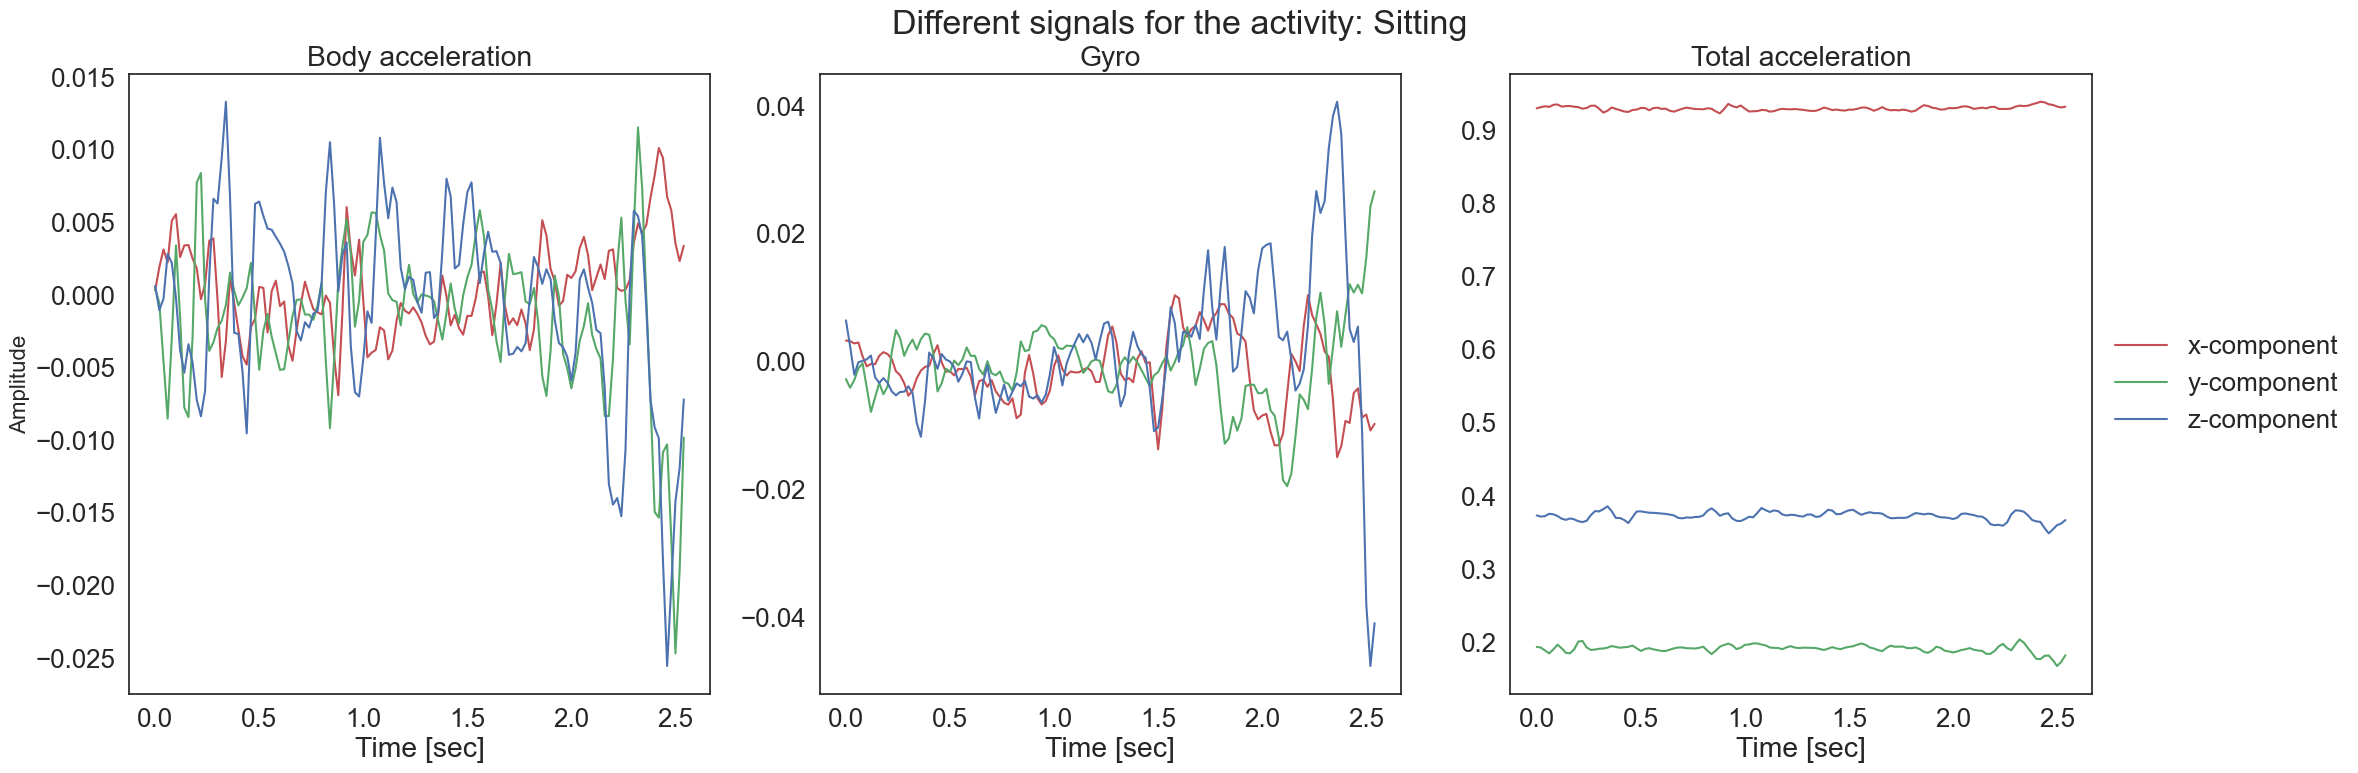

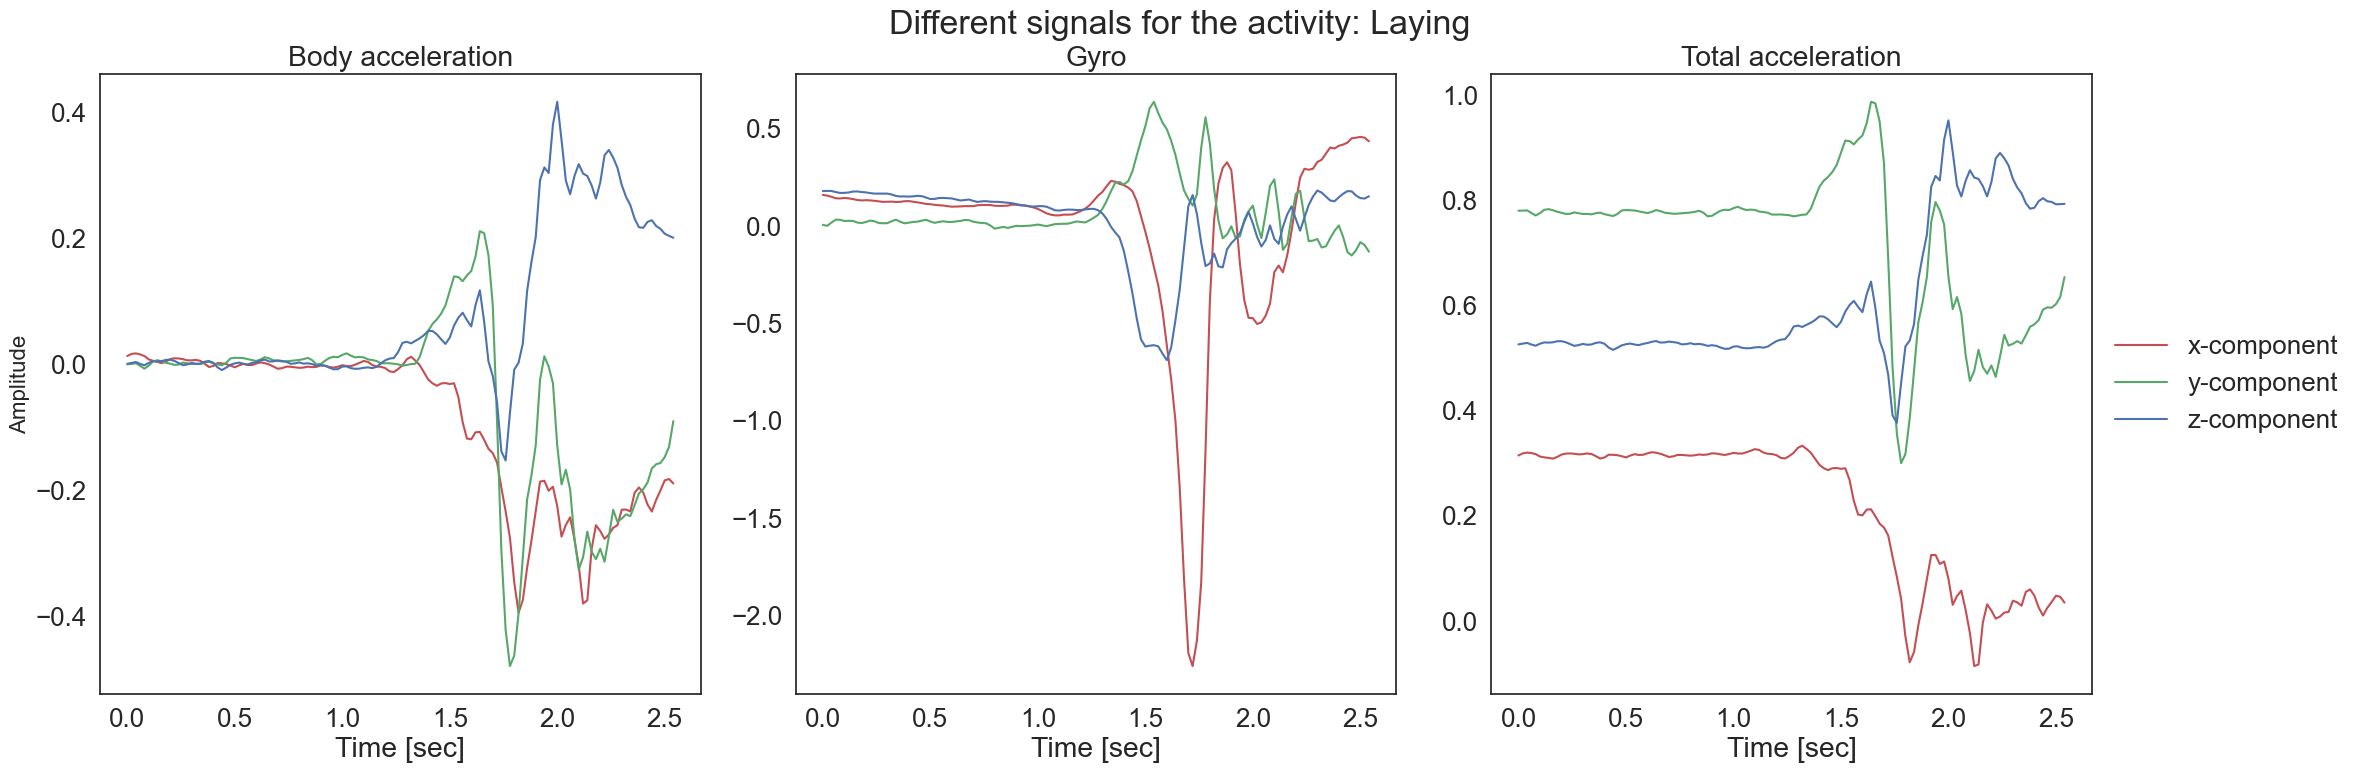

In [10]:
for i in sample:
    signal_viz(i)

Interesting visualisation, but difficult to interpret. In reality these xyz signals for each features works together to provide the insight, therefore we should visualise the data of xyz together.

### 3D Plots for the Body Acceleration Feature

In [11]:
# Plot the selected feature signal in 3D
def signal_3dviz(obs,feature):
    graph_name="graph/3D {} {}.png"
    activity_name = activities(obs)

    i=features(feature)

    sns.set(style="white", font_scale = 1)
    fig = plt.figure(figsize=(7,7))
    ax = fig.add_subplot(projection="3d")
    x = X_train[obs][:, i*3+0]
    y = X_train[obs][:, i*3+1]
    z = X_train[obs][:, i*3+2]
    ax.plot(x, y, z, label=feature)
    ax.legend()
    plt.title(activity_name)
    plt.xlabel("x")
    plt.ylabel("y")
    ax.set_zlabel("z")
    # Get rid of colored axes planes
    # First remove fill
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False

    # Bonus: To get rid of the grid as well:
    ax.grid(False)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    for t in ax.zaxis.get_ticklabels(): t.set_fontsize(12)
    plt.show()

Sample 777


/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/2674526311.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return activity[int(y_train[obs])]


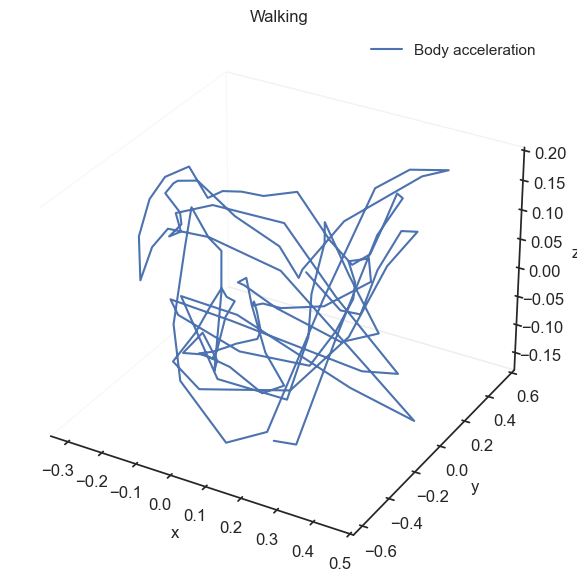

Sample 666


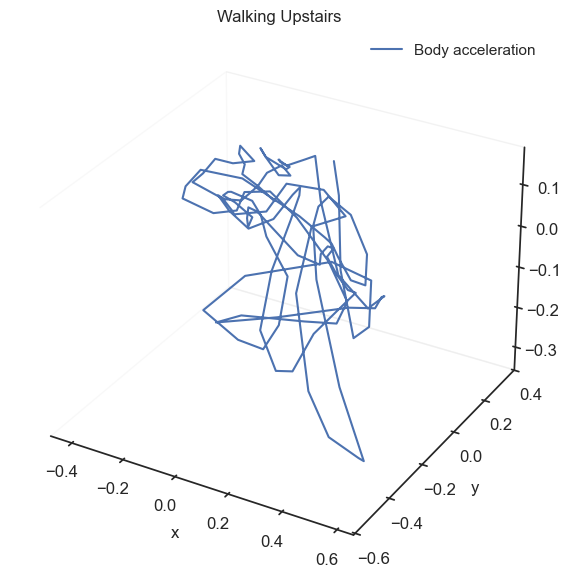

Sample 818


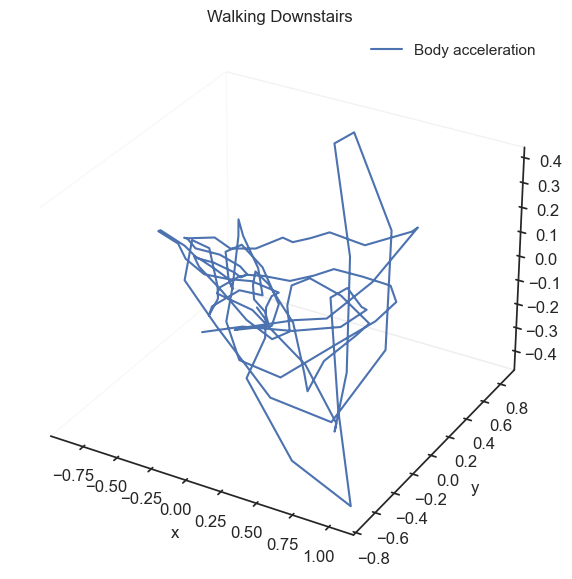

Sample 0


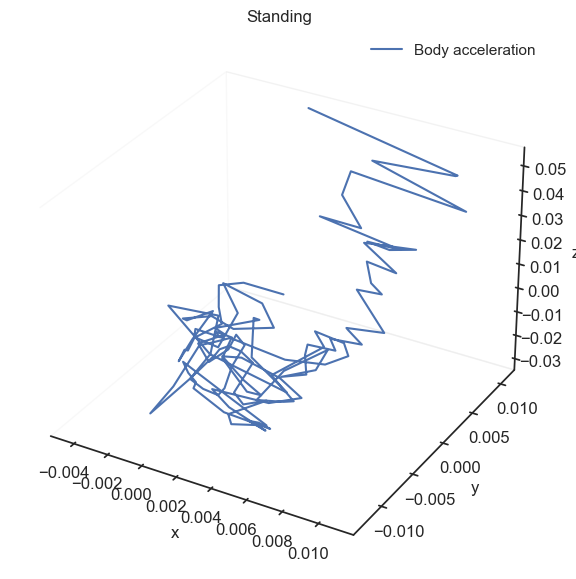

Sample 6666


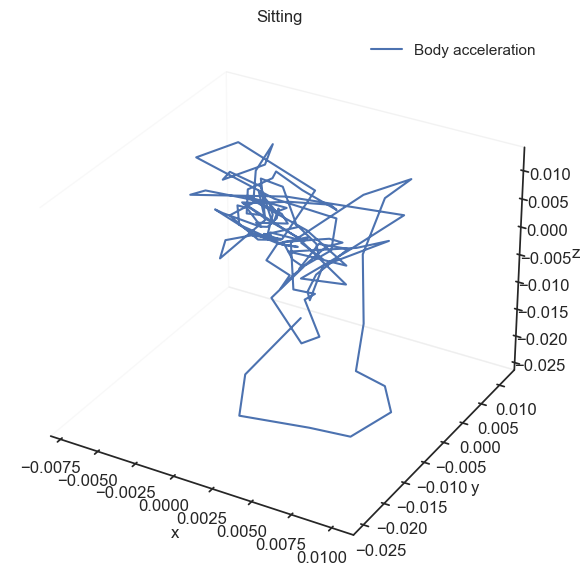

Sample 66


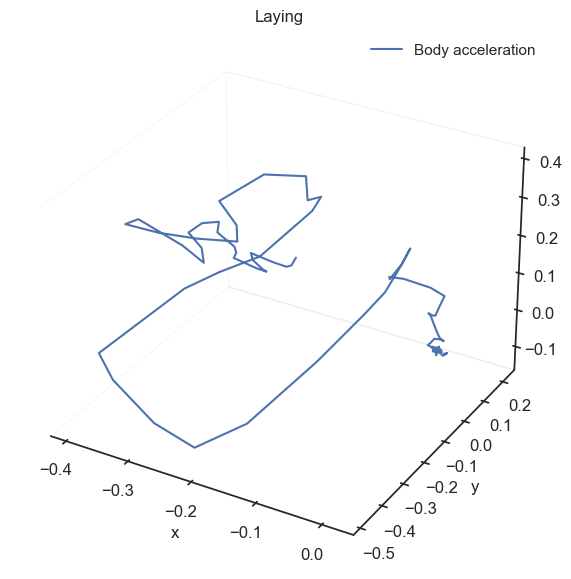

In [12]:
for i in sample:
    print("Sample", i)
    signal_3dviz(i, "Body acceleration")

Still very hard to make sense out of and to do any visual comparisons between the activities.
Will try to compute the distance of each timesteps to the origin (xyz = (0,0,0))

### Distance to Origin the Body Acceleration Feature

In [13]:
# Calculate the distance of each timesteps to origin (0,0,0)
def distance_viz(obs, feature):
    graph_name="graph/distance {} {}.png"
    activity_name = activities(obs)

    i=features(feature)

    sns.set(style="white", font_scale = 1)
    fig = plt.figure(figsize=(7,5))
    x = X_train[obs][:, i*3+0]
    y = X_train[obs][:, i*3+1]
    z = X_train[obs][:, i*3+2]
    plt.plot((x**2+y**2+z**2)**0.5, label=feature)
    plt.legend()
    plt.title(activity_name)
    plt.xlabel("Timesteps")
    plt.ylabel("Distance")
    plt.show()

Sample 777


/var/folders/5_/qd3xf9ls41q96mn9vn2661ph0000gn/T/ipykernel_78149/2674526311.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return activity[int(y_train[obs])]


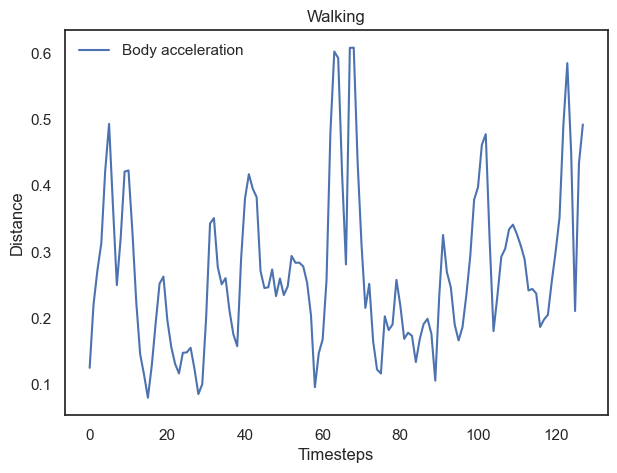

Sample 666


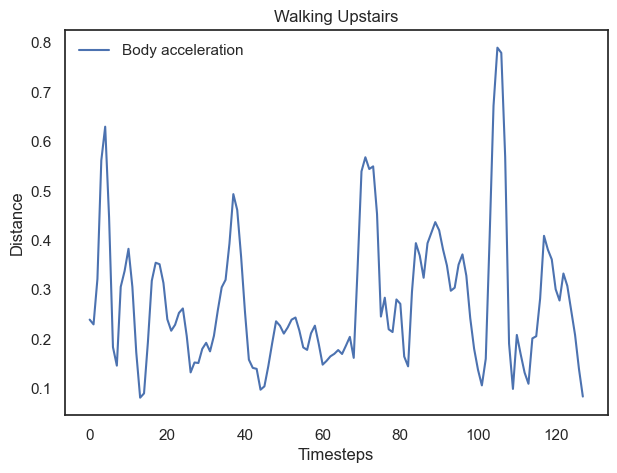

Sample 818


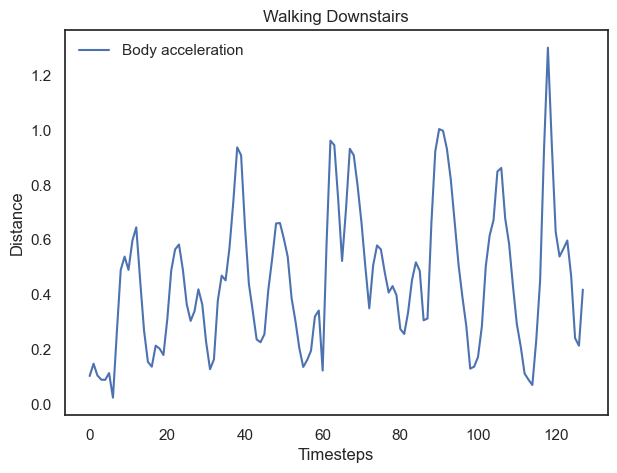

Sample 0


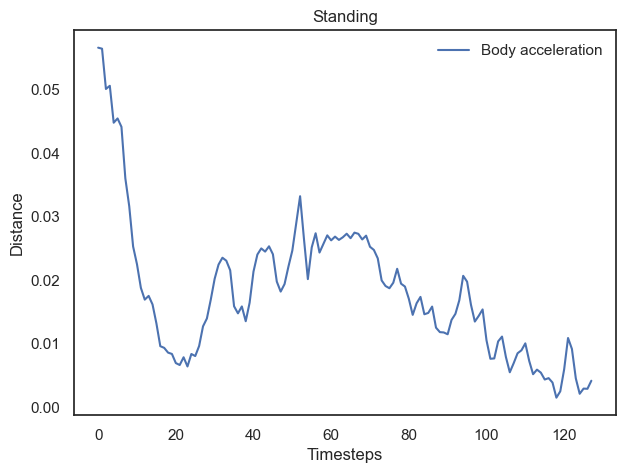

Sample 6666


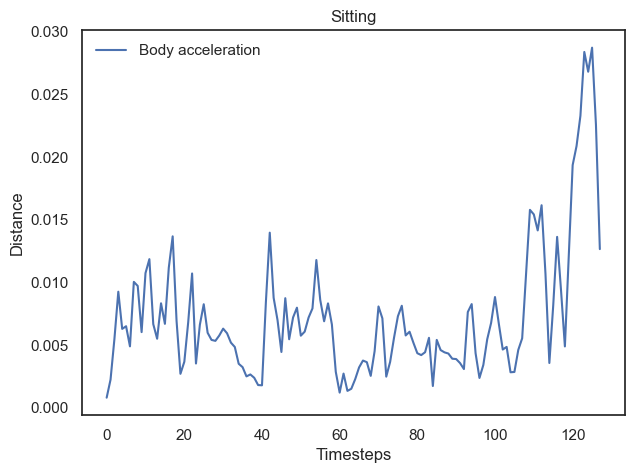

Sample 66


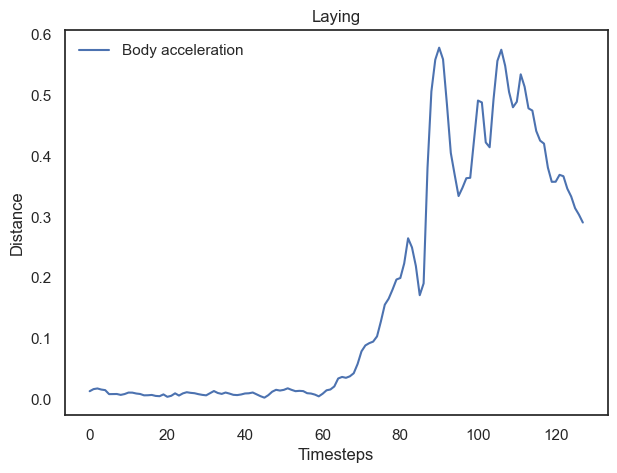

In [14]:
for i in sample:
    print("Sample", i)
    distance_viz(i, "Body acceleration")

It is now easier for us human eyes to compare the feature signals between different activities.

### EDA - Observations by Activity

In [15]:
def y_graph():
    y=pd.DataFrame(np.concatenate((y_train, y_test)), columns=["Activity"])
    y["Activity"]=y.Activity.map(activity)
    sns.set(style="white", font_scale=3)
    f, ax = plt.subplots(figsize=(40,15))
    sns.countplot(data=y, y="Activity")
    plt.title("Observations by Activity")
    plt.show()

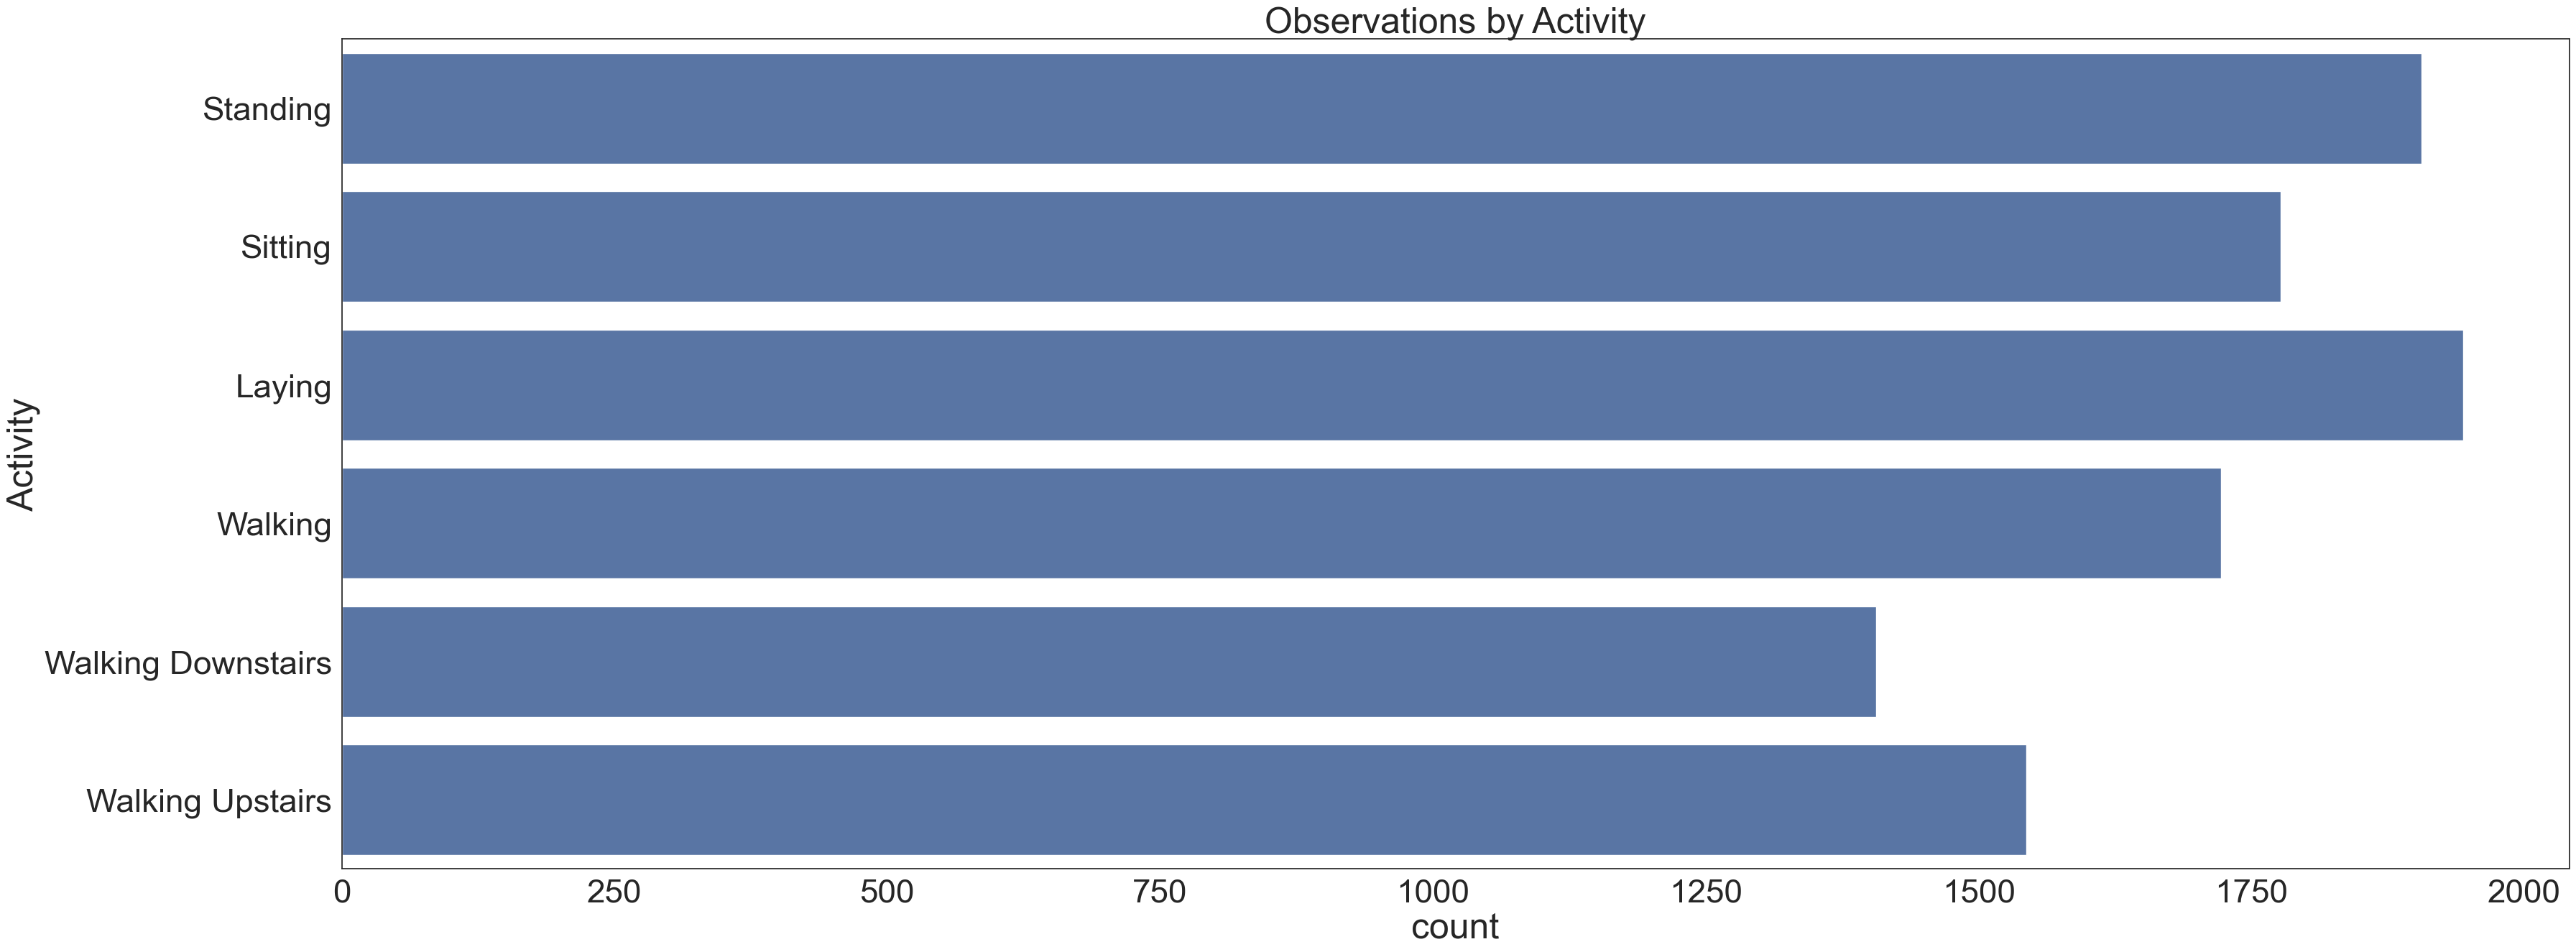

In [16]:
y_graph()

## Домашнее задание

1. Попробуйте вывасти распределение по классам для тестовой и тренировочной выборки
2. Придумайте самостоятельно визуализацию каких-либо закономерностей в предложенных данных

### Выполнение домашнего задания

Ниже отдельно сравним распределение активностей в тренировочной и тестовой выборках, а затем посмотрим, как отличаются суммарные амплитуды сигналов акселерометра и гироскопа для разных типов движения.

In [17]:
train_classes = pd.Series(y_train.ravel(), name='Activity').map(activity)
test_classes = pd.Series(y_test.ravel(), name='Activity').map(activity)

class_distribution = pd.concat([
    train_classes.value_counts().rename('Train'),
    test_classes.value_counts().rename('Test')
], axis=1).loc[list(activity.values())]

class_distribution['Train share'] = class_distribution['Train'] / class_distribution['Train'].sum()
class_distribution['Test share'] = class_distribution['Test'] / class_distribution['Test'].sum()
class_distribution

,Train,Test,Train share,Test share
Activity,,,,
Walking,1226,496,0.166757,0.168307
Walking Upstairs,1073,471,0.145947,0.159824
Walking Downstairs,986,420,0.134113,0.142518
Sitting,1286,491,0.174918,0.166610
Standing,1374,532,0.186888,0.180523
Laying,1407,537,0.191376,0.182219


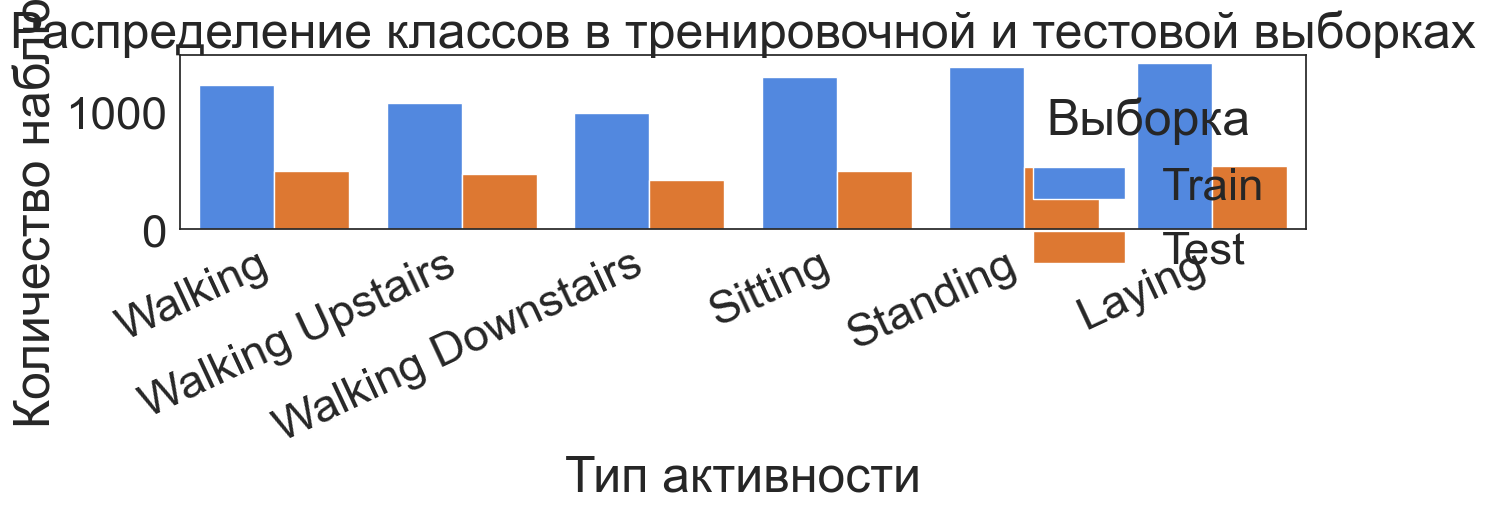

In [18]:
distribution_long = pd.concat([
    pd.DataFrame({'Activity': train_classes, 'Sample': 'Train'}),
    pd.DataFrame({'Activity': test_classes, 'Sample': 'Test'})
], ignore_index=True)

plt.figure(figsize=(14, 6))
sns.countplot(
    data=distribution_long,
    x='Activity',
    hue='Sample',
    order=list(activity.values()),
    palette=['#3b82f6', '#f97316']
)
plt.title('Распределение классов в тренировочной и тестовой выборках')
plt.xlabel('Тип активности')
plt.ylabel('Количество наблюдений')
plt.xticks(rotation=25, ha='right')
plt.legend(title='Выборка')
plt.tight_layout()
plt.show()

Распределение классов в train/test выборках близкое: все шесть активностей представлены в обеих частях датасета, поэтому дальше сравнение сигналов по классам не будет сильно искажено отсутствием какого-либо класса.

In [19]:
def build_signal_features(X, y, sample_name):
    labels = pd.Series(y.ravel()).map(activity)
    body_acc = np.sqrt((X[:, :, 0:3] ** 2).sum(axis=2))
    gyro = np.sqrt((X[:, :, 3:6] ** 2).sum(axis=2))
    total_acc = np.sqrt((X[:, :, 6:9] ** 2).sum(axis=2))

    return pd.DataFrame({
        'Activity': labels,
        'Sample': sample_name,
        'Mean body acceleration': body_acc.mean(axis=1),
        'Mean gyro': gyro.mean(axis=1),
        'Mean total acceleration': total_acc.mean(axis=1),
        'Std body acceleration': body_acc.std(axis=1)
    })

signal_features = pd.concat([
    build_signal_features(X_train, y_train, 'Train'),
    build_signal_features(X_test, y_test, 'Test')
], ignore_index=True)

signal_features.groupby('Activity')[['Mean body acceleration', 'Mean gyro', 'Mean total acceleration', 'Std body acceleration']].mean().loc[list(activity.values())]

,Mean body acceleration,Mean gyro,Mean total acceleration,Std body acceleration
Activity,,,,
Walking,0.287754,0.704526,1.051225,0.123307
Walking Upstairs,0.310834,0.797816,1.046625,0.139419
Walking Downstairs,0.379477,0.844657,1.041864,0.206588
Sitting,0.019691,0.055587,1.021483,0.013014
Standing,0.019849,0.060002,1.032974,0.011692
Laying,0.024302,0.063592,1.007277,0.014328


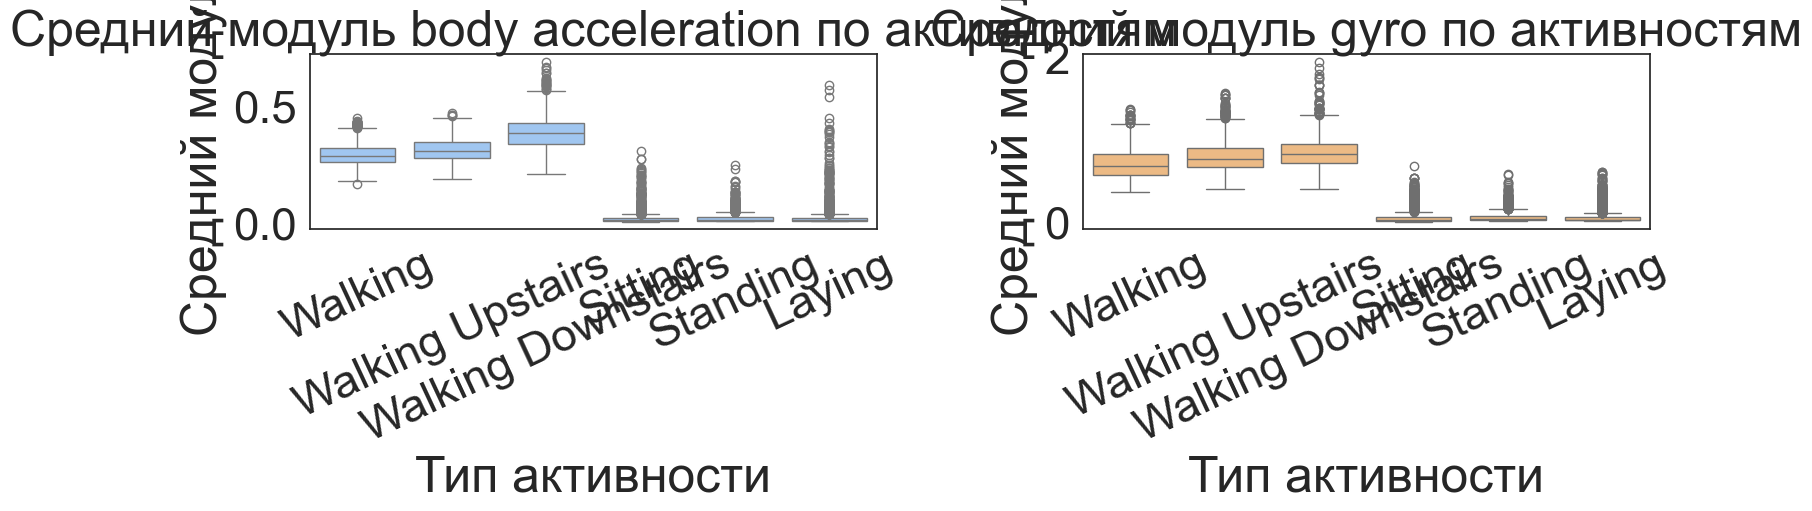

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(
    data=signal_features,
    x='Activity',
    y='Mean body acceleration',
    order=list(activity.values()),
    color='#93c5fd',
    ax=axes[0]
)
axes[0].set_title('Средний модуль body acceleration по активностям')
axes[0].set_xlabel('Тип активности')
axes[0].set_ylabel('Средний модуль')
axes[0].tick_params(axis='x', rotation=25)

sns.boxplot(
    data=signal_features,
    x='Activity',
    y='Mean gyro',
    order=list(activity.values()),
    color='#fdba74',
    ax=axes[1]
)
axes[1].set_title('Средний модуль gyro по активностям')
axes[1].set_xlabel('Тип активности')
axes[1].set_ylabel('Средний модуль')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

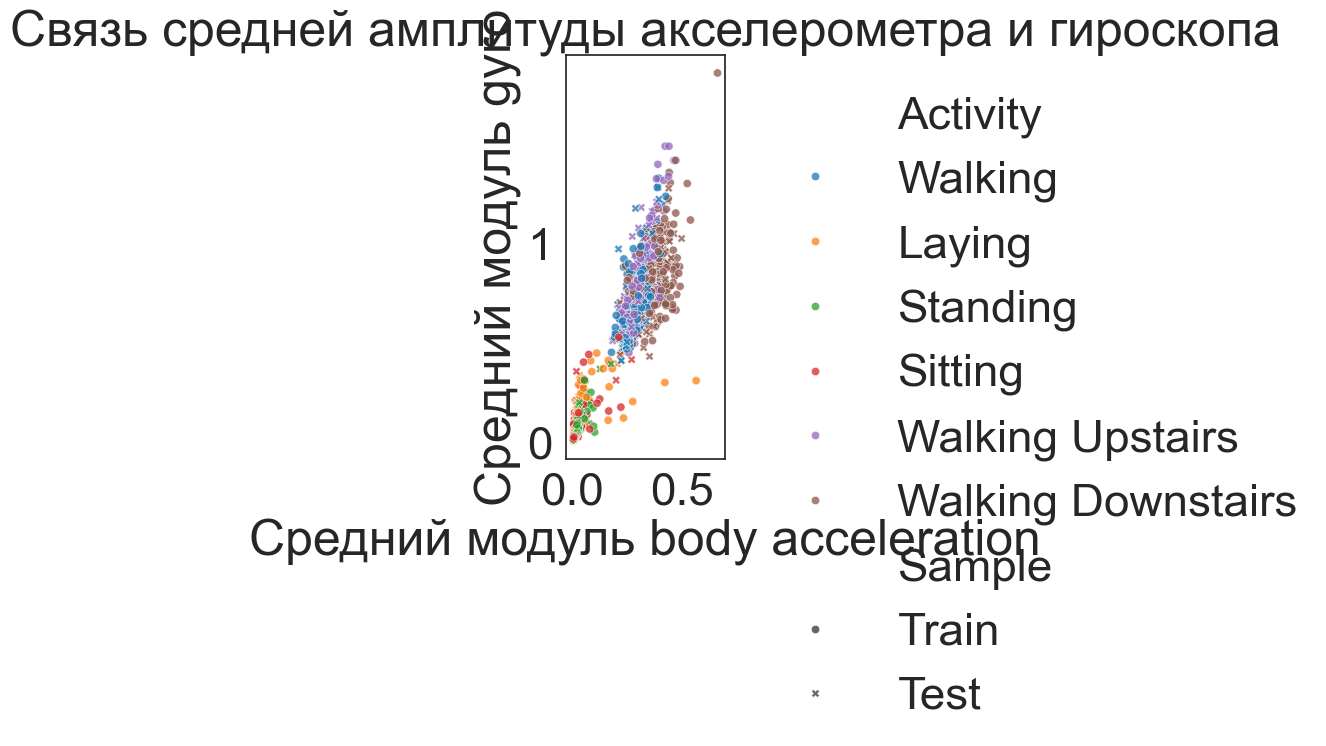

In [21]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=signal_features.sample(min(1500, len(signal_features)), random_state=42),
    x='Mean body acceleration',
    y='Mean gyro',
    hue='Activity',
    style='Sample',
    alpha=0.75,
    palette='tab10'
)
plt.title('Связь средней амплитуды акселерометра и гироскопа')
plt.xlabel('Средний модуль body acceleration')
plt.ylabel('Средний модуль gyro')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

По суммарной амплитуде сигналов хорошо отделяются статичные активности (`Sitting`, `Standing`, `Laying`) от динамичных (`Walking`, `Walking Upstairs`, `Walking Downstairs`). У ходьбы и подъема/спуска выше разброс по акселерометру и гироскопу, потому что движение создает регулярные изменения ускорений и угловых скоростей.